In [1]:
import numpy as np
import matplotlib.pylab as pl
import ot
import pandas as pd
import os

In [10]:
directory='iicd26-celltracking-ot-exploration/data'
entries = os.listdir(os.path.join(directory,'exp1/rep00/snapshots'))
print(entries)


def run_experiment(file1,file2):
    file1_path = os.path.join(directory, 'exp1/rep00/snapshots', file1)
    file2_path = os.path.join(directory, 'exp1/rep00/snapshots', file2)

    xs = pd.read_csv(file1_path).to_numpy()
    xt = pd.read_csv(file2_path).to_numpy()

    a, b = np.ones((xs.shape[0],)) / xs.shape[0], np.ones((xt.shape[0],)) / xt.shape[0]  # uniform distribution on samples

    # loss matrix
    M = ot.dist(xs, xt)
    M /= M.max()

    reg = 0.005
    reg_m_kl = 0.05
    reg_m_l2 = 5
    mass = 0.7

    entropic_kl_uot = ot.unbalanced.sinkhorn_unbalanced(a, b, M, reg, reg_m_kl)
    kl_uot = ot.unbalanced.mm_unbalanced(a, b, M, reg_m_kl, div="kl")
    l2_uot = ot.unbalanced.mm_unbalanced(a, b, M, reg_m_l2, div="l2")
    partial_ot = ot.partial.partial_wasserstein(a, b, M, m=mass)

    pl.figure(2)
    transp = [partial_ot, l2_uot, kl_uot, entropic_kl_uot]
    title = [
        "partial OT \n m=" + str(mass),
        "$\ell_2$-UOT \n $\mathrm{reg_m}$=" + str(reg_m_l2),
        "kl-UOT \n $\mathrm{reg_m}$=" + str(reg_m_kl),
        "entropic kl-UOT \n $\mathrm{reg_m}$=" + str(reg_m_kl),
    ]

    for p in range(4):
        pl.subplot(2, 4, p + 1)
        P = transp[p]
        if P.sum() > 0:
            P = P / P.max()
        for i in range(xs.shape[0]):
            for j in range(xt.shape[0]):
                if P[i, j] > -1e-10:
                    pl.plot(
                        [xs[i, 0], xt[j, 0]],
                        [xs[i, 1], xt[j, 1]],
                        color="C2",
                        alpha=P[i, j] * 0.3,
                    )
        pl.scatter(xs[:, 0], xs[:, 1], c="y", alpha=0.2)
        pl.scatter(xt[:, 0], xt[:, 1], c="b", alpha=0.2)
        pl.scatter(xs[:, 0], xs[:, 1], c="r", s=P.sum(1).ravel() * (1 + p) * 2)
        pl.scatter(xt[:, 0], xt[:, 1], c="g", s=P.sum(0).ravel() * (1 + p) * 2)
        pl.title(title[p])
        #pl.yticks(())
        #pl.xticks(())
        if p < 1:
            pl.ylabel("mappings")
        pl.subplot(2, 4, p + 5)
        pl.imshow(P, cmap="jet")
        pl.yticks(())
        pl.xticks(())
        if p < 1:
            pl.ylabel("transport plans")
    pl.show()

    return transp

['t0.csv', 't1.csv', 't2.csv']


<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2590174/1754894606.py:33: SyntaxWarning: invalid escape sequence '\e'
  "$\ell_2$-UOT \n $\mathrm{reg_m}$=" + str(reg_m_l2),
/tmp/ipykernel_2590174/1754894606.py:34: SyntaxWarning: invalid escape sequence '\m'
  "kl-UOT \n $\mathrm{reg_m}$=" + str(reg_m_kl),
/tmp/ipykernel_2590174/1754894606.py:35: SyntaxWarning: invalid escape sequence '\m'
  "entropic kl-UOT \n $\mathrm{reg_m}$=" + str(reg_m_kl),


In [7]:
file1='t0.csv'
file2='t1.csv'
file1_path = os.path.join(directory, 'exp1/rep00/snapshots', file1)
file2_path = os.path.join(directory, 'exp1/rep00/snapshots', file2)

xs = pd.read_csv(file1_path)
xt = pd.read_csv(file2_path)

xs.describe()


,obs_id,x,y
count,100.000000,100.000000,100.000000
mean,49.500000,9.433764,9.751329
std,29.011492,5.983263,5.969233
min,0.000000,0.013455,0.400528
25%,24.750000,3.999032,4.167869
50%,49.500000,9.051768,10.197961
75%,74.250000,14.320267,14.856893
max,99.000000,19.860390,19.934635


In [20]:
xt.describe()

,obs_id,x,y
count,185.000000,185.000000,185.000000
mean,92.000000,9.376332,9.426211
std,53.549043,5.949389,6.025304
min,0.000000,-0.263107,-0.034499
25%,46.000000,4.126798,3.545209
50%,92.000000,8.985119,9.786921
75%,138.000000,13.996710,14.549327
max,184.000000,20.031137,21.138683


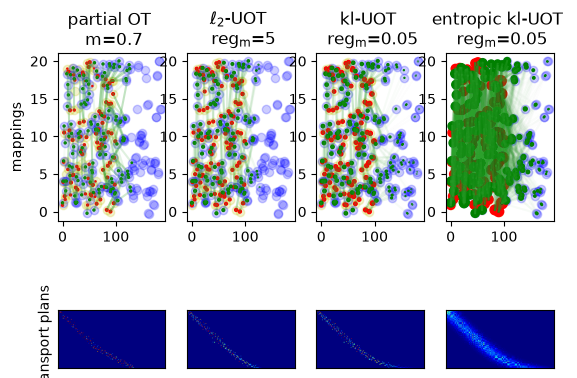

[array([[0.00540541, 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.00540541, 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.00540541, ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ]], shape=(100, 185)),
 array([[7.51169798e-03, 1.62616314e-04, 3.33871863e-31, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.80180495e-04, 7.50064520e-03, 2.53222359e-26, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.06291321e-36, 8.62686908e-34, 5.78764147e-03, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.0000000

In [11]:
t0_t1_res = run_experiment('t0.csv', 't1.csv')

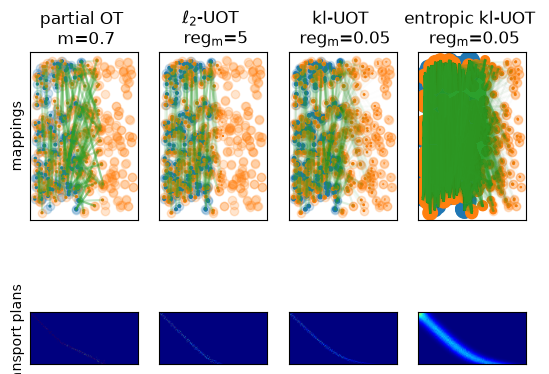

In [15]:
run_experiment('t1.csv', 't2.csv')